# MFCC

In [4]:
import os
import numpy as np
import gdown
import zipfile
from sklearn.model_selection import train_test_split
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve,auc,precision_recall_curve,average_precision_score

In [5]:
DATASET_PATH = "dataset"

if not os.path.exists(DATASET_PATH):
    print("Skidanje dataseta...")

    gdown.download(
        "https://drive.google.com/uc?id=1k-b9EkXcOALbQFrMmHG-arjAa_KrL15v",
        "dataset.zip",
        quiet=False
    )

    print("Raspakivanje...")
    with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
        zip_ref.extractall(DATASET_PATH)

    os.remove("dataset.zip")
    print("Gotovo!")
else:
    print("Dataset već postoji lokalno.")

dataset_path = os.path.join(DATASET_PATH,"dataset_wake_word_detection")
wake_word = "stop"

wake_word_folder= os.path.join(dataset_path,wake_word)

Dataset već postoji lokalno.


In [6]:
files= os.listdir(wake_word_folder)

#primer jednog audio fajla
audio_file= os.path.join(wake_word_folder,files[0])

In [7]:
signal, sr= librosa.load(audio_file,sr=16000)
print("Sample rate:", sr)
print("Signal shape:", signal.shape)

/home/jovana/Desktop/projects/Wake  word detection/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample rate: 16000
Signal shape: (16000,)


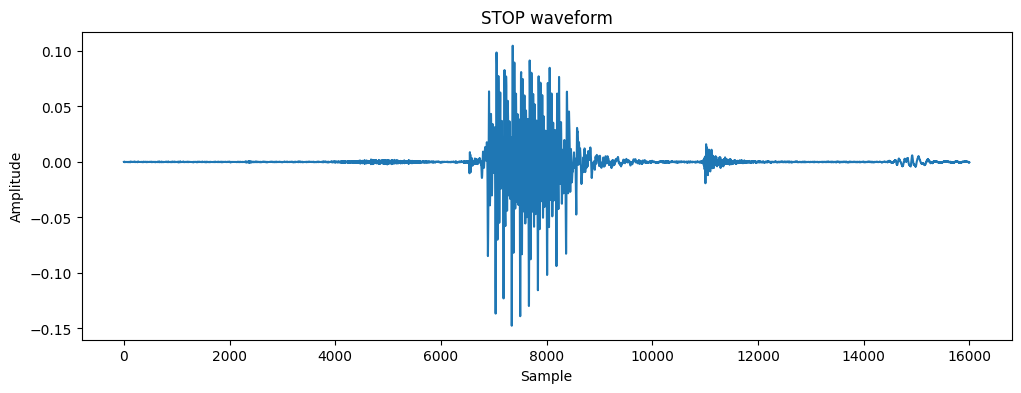

In [8]:
plt.figure(figsize=(12,4))
plt.plot(signal)
plt.title("STOP waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [9]:
Audio(signal, rate=sr)

In [10]:
mfcc= librosa.feature.mfcc(y=signal,sr=sr,n_mfcc=13)
print(mfcc.shape)

(13, 32)


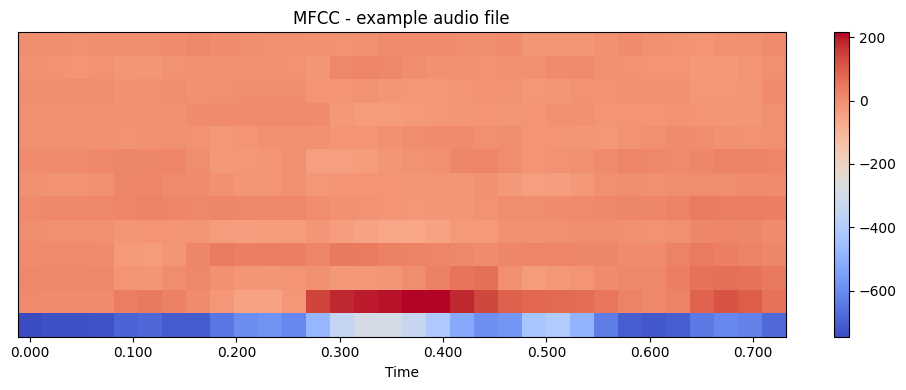

In [11]:
plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc,x_axis='time')

plt.colorbar()
plt.title("MFCC - example audio file")
plt.tight_layout()
plt.show()

In [12]:
def extract_mfcc(file_path, n_mfcc=13, max_len=32):
    signal, sr= librosa.load(file_path,sr=16000)

    mfcc= librosa.feature.mfcc(y=signal,sr=sr,n_mfcc=n_mfcc)
    
    if mfcc.shape[1] < max_len:
        pad_width= max_len - mfcc.shape[1]

        mfcc= np.pad(mfcc,pad_width=((0,0),(0,pad_width)),mode='constant')
    else:
        mfcc= mfcc[:, :max_len]

    return mfcc

In [13]:
X= []
y= []

In [14]:
for file_name in os.listdir(wake_word_folder):
    if file_name.endswith(".wav"):
        file_path= os.path.join(wake_word_folder,file_name)

        mfcc= extract_mfcc(file_path)

        X.append(mfcc)
        y.append(1)

In [15]:
for folder_name in os.listdir(dataset_path):
    folder_path= os.path.join(dataset_path,folder_name)

    if not os.path.isdir(folder_path):
        continue

    if folder_name == wake_word:
        continue

    for file_name in os.listdir(folder_path):
        if file_name.endswith(".wav"):
            file_path= os.path.join(folder_path,file_name)

            mfcc = extract_mfcc(file_path)

            X.append(mfcc)
            y.append(0)

In [16]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (64727, 13, 32)
y shape: (64727,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (48545, 13, 32)
X_test: (16182, 13, 32)
y_train: (48545,)
y_test: (16182,)


In [18]:
X_train_tensor= torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor= torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)
y_train_tensor= torch.tensor(y_train, dtype=torch.float32)
y_test_tensor= torch.tensor(y_test,  dtype=torch.float32)

train_dataset= TensorDataset(X_train_tensor, y_train_tensor)
test_dataset= TensorDataset(X_test_tensor,  y_test_tensor)

train_loader= DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader= DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [19]:
class WakeWordCnnMfcc(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1= nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1= nn.BatchNorm2d(16)
        self.conv2= nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2= nn.BatchNorm2d(32)
        self.pool= nn.MaxPool2d(2)
        self.relu= nn.ReLU()
        self.global_pool= nn.AdaptiveAvgPool2d((1, 1))
        self.fc1= nn.Linear(32, 64)
        self.dropout= nn.Dropout(0.3)
        self.fc2= nn.Linear(64, 1)

    def forward(self, x):
        x= self.conv1(x)
        x= self.bn1(x)
        x= self.relu(x)
        x= self.pool(x)

        x= self.conv2(x)
        x= self.bn2(x)
        x= self.relu(x)
        x= self.pool(x)

        x= self.global_pool(x)

        x= x.view(x.size(0), -1)

        x= self.fc1(x)
        x= self.relu(x)

        x= self.dropout(x)

        x= self.fc2(x)

        return x

In [20]:
num_negative= (y_train == 0).sum()
num_positive= (y_train == 1).sum()
pos_weight= torch.tensor([num_negative / num_positive], dtype=torch.float32)

mfcc_model= WakeWordCnnMfcc()
criterion= nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer= optim.Adam(mfcc_model.parameters(), lr=0.001)

In [21]:
num_epochs= 20
train_losses= []
for epoch in range(num_epochs):
    mfcc_model.train()
    running_loss= 0.0
    for inputs, labels in train_loader:
        labels= labels.unsqueeze(1)
        optimizer.zero_grad()
        outputs= mfcc_model(inputs)
        loss= criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() #mozda zameniti ovo da se prikazuje samo epoch_loss, ali svejedno je

    epoch_loss= running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"MFCC Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss:.4f}")

MFCC Epoch [1/20] Loss: 1165.9938
MFCC Epoch [2/20] Loss: 622.0097
MFCC Epoch [3/20] Loss: 459.1389
MFCC Epoch [4/20] Loss: 401.8669
MFCC Epoch [5/20] Loss: 375.5435
MFCC Epoch [6/20] Loss: 322.3443
MFCC Epoch [7/20] Loss: 303.4067
MFCC Epoch [8/20] Loss: 291.5714
MFCC Epoch [9/20] Loss: 263.9075
MFCC Epoch [10/20] Loss: 265.4114
MFCC Epoch [11/20] Loss: 260.5561
MFCC Epoch [12/20] Loss: 260.1525
MFCC Epoch [13/20] Loss: 224.5754
MFCC Epoch [14/20] Loss: 214.0919
MFCC Epoch [15/20] Loss: 233.9674
MFCC Epoch [16/20] Loss: 211.4500
MFCC Epoch [17/20] Loss: 208.6531
MFCC Epoch [18/20] Loss: 186.4202
MFCC Epoch [19/20] Loss: 173.4211
MFCC Epoch [20/20] Loss: 190.1006


In [24]:
mfcc_model.eval()
all_probs,all_preds, all_labels= [], [], []

#dodati mozda validacioni skup da se proveri koji threshold je najbolji za razlicite trenirane modele
threshold= 0.7

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs= torch.sigmoid(mfcc_model(inputs))
        preds= (outputs >= threshold).float()
        all_probs.extend(outputs.squeeze().numpy())
        all_preds.extend(preds.squeeze().numpy())
        all_labels.extend(labels.numpy())

mfcc_accuracy= accuracy_score(all_labels, all_preds)
print("MFCC Accuracy:", mfcc_accuracy)
print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, zero_division=0))

MFCC Accuracy: 0.9939438882709183
[[15570    17]
 [   81   514]]
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     15587
         1.0       0.97      0.86      0.91       595

    accuracy                           0.99     16182
   macro avg       0.98      0.93      0.95     16182
weighted avg       0.99      0.99      0.99     16182



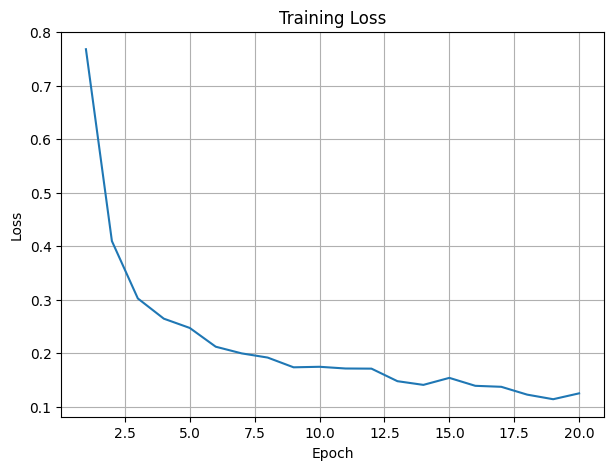

In [25]:
plt.figure(figsize=(7,5))
plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

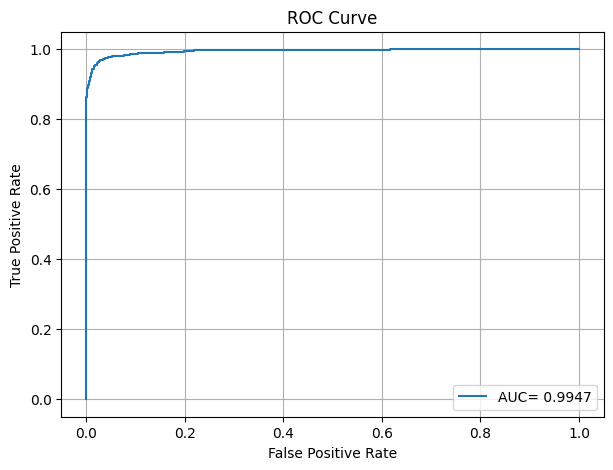

In [26]:
fpr, tpr, roc_thresholds= roc_curve(all_labels, all_probs)
roc_auc= auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC= {roc_auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

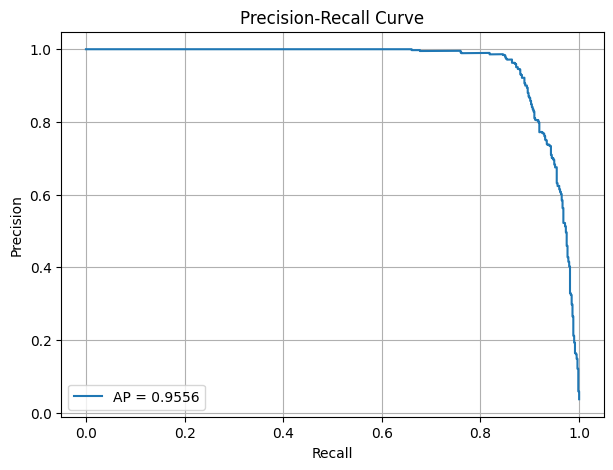

In [27]:
precision, recall, pr_thresholds= precision_recall_curve(all_labels,all_probs)
ap_score= average_precision_score(all_labels, all_probs)

plt.figure(figsize=(7,5))
plt.plot(recall, precision,label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

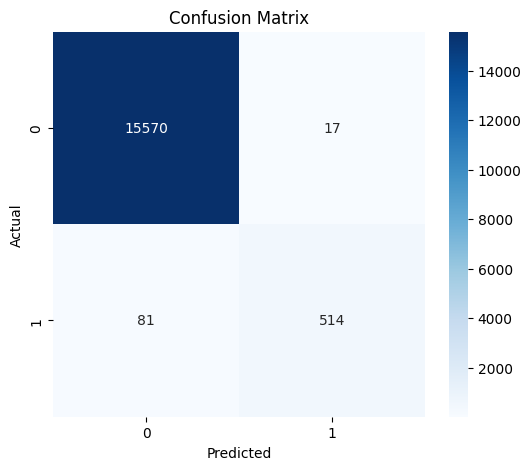

In [28]:
cm= confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# LFCC

In [51]:
import os
import numpy as np
import librosa
import scipy.fftpack

### Funkcija koja pretvara zvučni signal u LFCC matricu

In [52]:
def extract_lfcc(
    file_path,
    n_lfcc=13,
    n_fft=512,
    hop_length=256,
    max_len=32
):

    signal, sr = librosa.load(
        file_path,
        sr=16000
    )

    stft = np.abs(
        librosa.stft(
            signal,
            n_fft=n_fft,
            hop_length=hop_length
        )
    )

    spectrogram = stft ** 2

    n_filters = 40

    freqs = np.linspace(
        0,
        sr // 2,
        n_filters + 2
    )

    fft_freqs = librosa.fft_frequencies(
        sr=sr,
        n_fft=n_fft
    )

    filter_bank = np.zeros(
        (n_filters, len(fft_freqs))
    )

    for i in range(1, n_filters + 1):

        left = freqs[i - 1]
        center = freqs[i]
        right = freqs[i + 1]

        for j, freq in enumerate(fft_freqs):

            if left <= freq <= center:

                filter_bank[i - 1, j] = (
                    (freq - left)
                    / (center - left)
                )

            elif center <= freq <= right:

                filter_bank[i - 1, j] = (
                    (right - freq)
                    / (right - center)
                )

    filtered_spectrum = np.dot(
        filter_bank,
        spectrogram
    )

    log_spectrum = np.log(
        filtered_spectrum + 1e-10
    )

    lfcc = scipy.fftpack.dct(
        log_spectrum,
        axis=0,
        norm='ortho'
    )

    lfcc = lfcc[:n_lfcc]

    if lfcc.shape[1] < max_len:

        pad_width = max_len - lfcc.shape[1]

        lfcc = np.pad(
            lfcc,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )

    else:

        lfcc = lfcc[:, :max_len]

    return lfcc

### Prikaz jedne LFCC matrice za reč STOP

In [53]:
audio_file = os.path.join(
    dataset_path,
    "stop",
    os.listdir(
        os.path.join(dataset_path, "stop")
    )[0]
)

lfcc = extract_lfcc(audio_file)

print(lfcc.shape)

(13, 32)


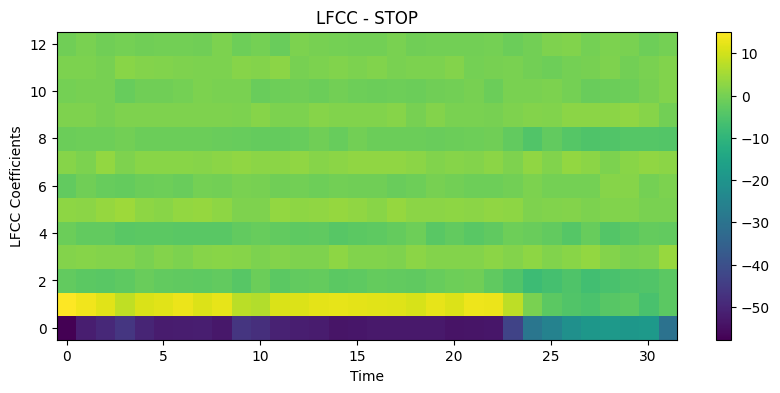

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.imshow(
    lfcc,
    aspect='auto',
    origin='lower'
)

plt.colorbar()
plt.title("LFCC - STOP")
plt.xlabel("Time")
plt.ylabel("LFCC Coefficients")
plt.show()

#### LFCC matrica prikazuje karakteristične promene frekvencijskih komponenti reči „STOP“ kroz vreme, pri čemu su najizraženije niže frekvencije tipične za govorni signal. Razlike u intenzitetu boja predstavljaju promene energije tokom izgovora reči, što omogućava modelu da prepozna njen jedinstveni obrazac.

### Učitavanje podataka i dodeljivanje klasa

In [55]:
X_lfcc = []
y_lfcc = []

In [56]:
stop_folder = os.path.join(
    dataset_path,
    "stop"
)

for file_name in os.listdir(stop_folder):

    if file_name.endswith(".wav"):

        file_path = os.path.join(
            stop_folder,
            file_name
        )

        lfcc = extract_lfcc(file_path)

        X_lfcc.append(lfcc)

        y_lfcc.append(1)

In [57]:
for folder_name in os.listdir(dataset_path):

    folder_path = os.path.join(
        dataset_path,
        folder_name
    )

    if not os.path.isdir(folder_path):
        continue

    if folder_name == "stop":
        continue

    if folder_name.startswith("_"):
        continue

    for file_name in os.listdir(folder_path):

        if file_name.endswith(".wav"):

            file_path = os.path.join(
                folder_path,
                file_name
            )

            lfcc = extract_lfcc(file_path)

            X_lfcc.append(lfcc)

            y_lfcc.append(0)

In [58]:
X_lfcc = np.array(X_lfcc)
y_lfcc = np.array(y_lfcc)

print(X_lfcc.shape)
print(y_lfcc.shape)

(64721, 13, 32)
(64721,)


### Podela na trening i test skup

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_lfcc_train, X_lfcc_test, y_lfcc_train, y_lfcc_test = train_test_split(
    X_lfcc,
    y_lfcc,
    test_size=0.25,
    random_state=42,
    stratify=y_lfcc
)

print("X_lfcc_train:", X_lfcc_train.shape)
print("X_lfcc_test:", X_lfcc_test.shape)
print("y_lfcc_train:", y_lfcc_train.shape)
print("y_lfcc_test:", y_lfcc_test.shape)

X_lfcc_train: (48540, 13, 32)
X_lfcc_test: (16181, 13, 32)
y_lfcc_train: (48540,)
y_lfcc_test: (16181,)


In [61]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

### CNN model

In [62]:
X_lfcc_train_tensor = torch.tensor(
    X_lfcc_train,
    dtype=torch.float32
)

X_lfcc_test_tensor = torch.tensor(
    X_lfcc_test,
    dtype=torch.float32
)

y_lfcc_train_tensor = torch.tensor(
    y_lfcc_train,
    dtype=torch.float32
)

y_lfcc_test_tensor = torch.tensor(
    y_lfcc_test,
    dtype=torch.float32
)

In [63]:
X_lfcc_train_tensor = X_lfcc_train_tensor.unsqueeze(1)
X_lfcc_test_tensor = X_lfcc_test_tensor.unsqueeze(1)

print(X_lfcc_train_tensor.shape)
print(X_lfcc_test_tensor.shape)

torch.Size([48540, 1, 13, 32])
torch.Size([16181, 1, 13, 32])


In [64]:
lfcc_train_dataset = TensorDataset(
    X_lfcc_train_tensor,
    y_lfcc_train_tensor
)

lfcc_test_dataset = TensorDataset(
    X_lfcc_test_tensor,
    y_lfcc_test_tensor
)

lfcc_train_loader = DataLoader(
    lfcc_train_dataset,
    batch_size=32,
    shuffle=True
)

lfcc_test_loader = DataLoader(
    lfcc_test_dataset,
    batch_size=32,
    shuffle=False
)

In [65]:
class WakeWordCNN(nn.Module):

    def __init__(self):

        super(WakeWordCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2
        )

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(
            32 * 3 * 8,
            64
        )

        self.fc2 = nn.Linear(
            64,
            1
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.sigmoid(x)

        return x

In [66]:
lfcc_model = WakeWordCNN()

print(lfcc_model)

WakeWordCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=768, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [67]:
lfcc_criterion = nn.BCELoss()


lfcc_optimizer = optim.Adam(
    lfcc_model.parameters(),
    lr=0.001
)

In [68]:
num_epochs = 10

train_losses = []

for epoch in range(num_epochs):

    lfcc_model.train()

    running_loss = 0.0

    for inputs, labels in lfcc_train_loader:

        labels = labels.unsqueeze(1)

        lfcc_optimizer.zero_grad()

        outputs = lfcc_model(inputs)

        loss = lfcc_criterion(
            outputs,
            labels
        )

        loss.backward()

        lfcc_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(lfcc_train_loader)

    train_losses.append(epoch_loss)

    print(
        f"LFCC Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

LFCC Epoch [1/10] Loss: 0.1055
LFCC Epoch [2/10] Loss: 0.0721
LFCC Epoch [3/10] Loss: 0.0625
LFCC Epoch [4/10] Loss: 0.0577
LFCC Epoch [5/10] Loss: 0.0542
LFCC Epoch [6/10] Loss: 0.0505
LFCC Epoch [7/10] Loss: 0.0475
LFCC Epoch [8/10] Loss: 0.0458
LFCC Epoch [9/10] Loss: 0.0434
LFCC Epoch [10/10] Loss: 0.0413


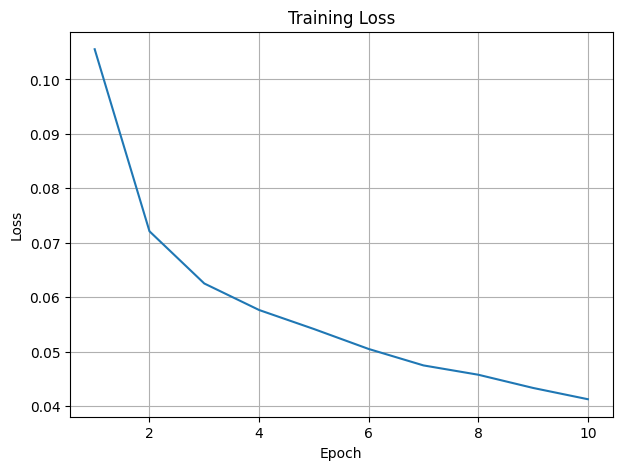

In [69]:
plt.figure(figsize=(7,5))
plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

### Evaluacija modela na test skupu

In [70]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [71]:
lfcc_model.eval()

WakeWordCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=768, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [72]:
all_predictions = []
all_labels = []
all_probs = []

In [73]:
with torch.no_grad():

    for inputs, labels in lfcc_test_loader:

        outputs = lfcc_model(inputs)

        predictions = (outputs >= 0.5).float()
        
        all_probs.extend(
            outputs.squeeze().numpy()
        )

        all_predictions.extend(
            predictions.squeeze().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [74]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print("LFCC Accuracy:", accuracy)

LFCC Accuracy: 0.9831901613002905


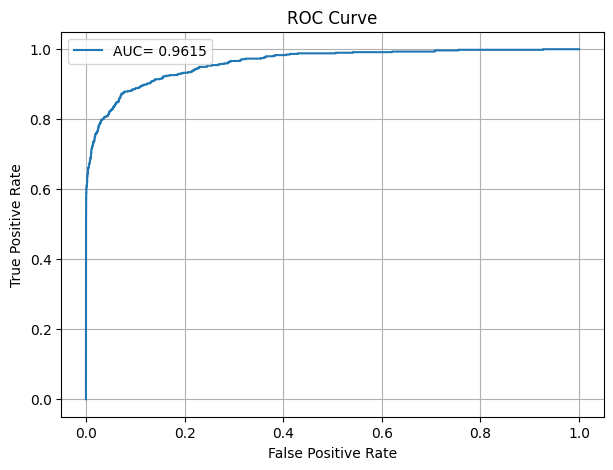

In [75]:
fpr, tpr, roc_thresholds= roc_curve(all_labels, all_probs)
roc_auc= auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC= {roc_auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

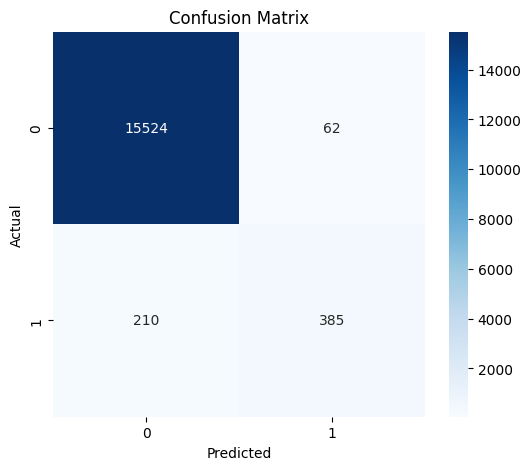

In [76]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [77]:
print(
    classification_report(
        all_labels,
        all_predictions
    )
)

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     15586
         1.0       0.86      0.65      0.74       595

    accuracy                           0.98     16181
   macro avg       0.92      0.82      0.87     16181
weighted avg       0.98      0.98      0.98     16181



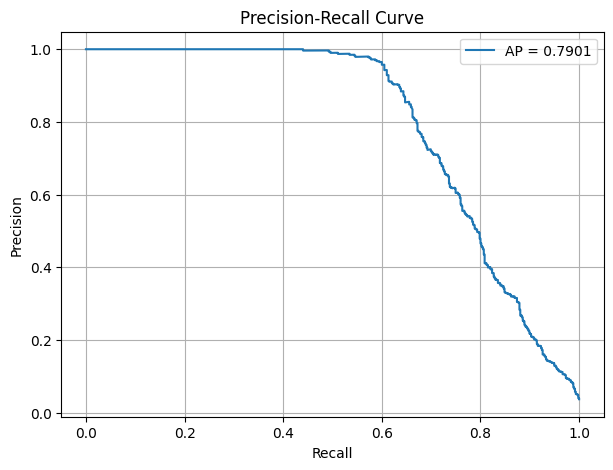

In [78]:
precision, recall, pr_thresholds= precision_recall_curve(all_labels,all_probs)
ap_score= average_precision_score(all_labels, all_probs)

plt.figure(figsize=(7,5))
plt.plot(recall, precision,label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

#### Model postiže precision vrednost od 0.86 za pozitivnu klasu, što ukazuje da većina detektovanih pozitivnih primera zaista pripada klasi ključne reči. Recall vrednost od 0.65 pokazuje da model uspešno prepoznaje značajan broj pozitivnih primera, ali i dalje propušta deo audio uzoraka koji sadrže ključnu reč. Takvo ponašanje je očekivano zbog nebalansiranosti skupa podataka i kompleksnosti audio klasifikacije.